imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Load Metrics

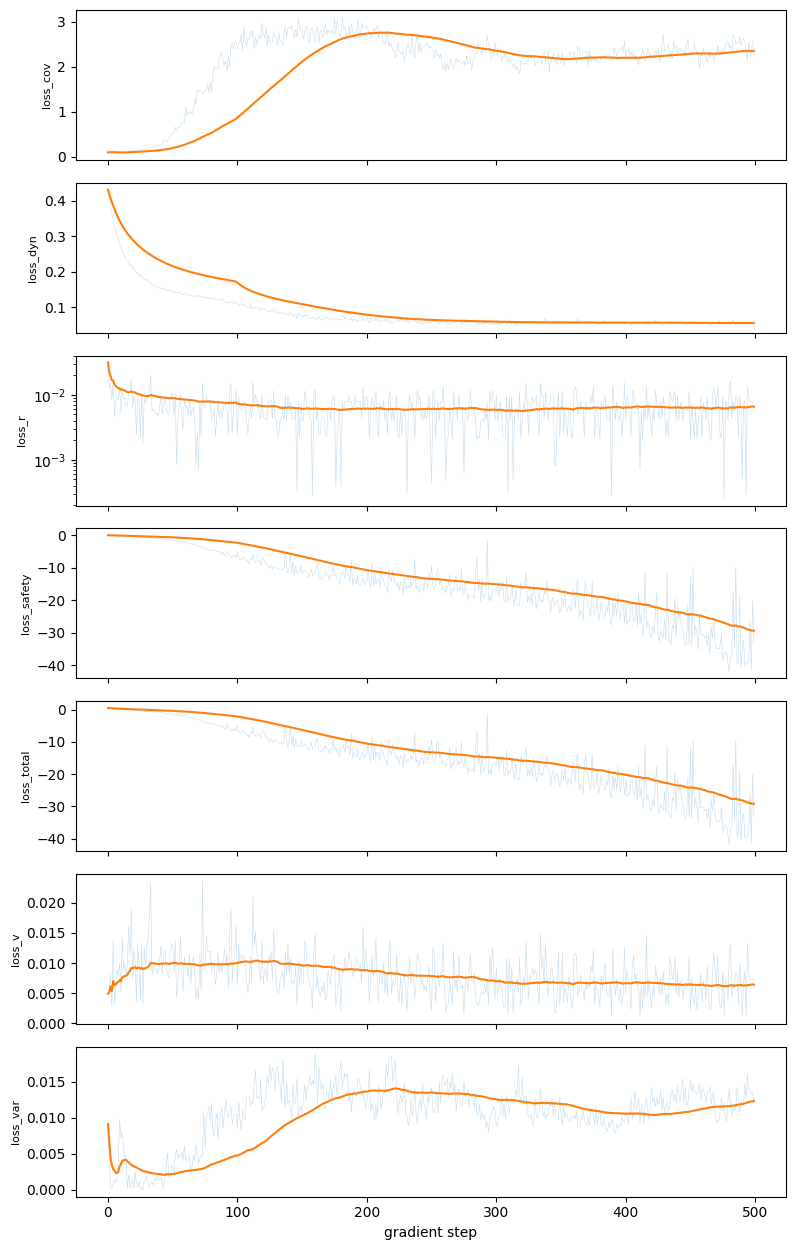

In [7]:
df = pd.read_csv("SaveData/testrun_pointgoal1_c_inf/Metrics/metrics.csv")

cols = [c for c in df.columns if c not in ("epoch", "batch", "step")]
fig, axes = plt.subplots(len(cols), 1, figsize=(8, 1.8 * len(cols)), sharex=True)

for ax, c in zip(axes, cols):
    ax.plot(df["step"], df[c], lw=0.4, alpha=0.25)                      # raw
    ax.plot(df["step"], df[c].rolling(100, min_periods=1).mean(), lw=1.5)  # smoothed
    ax.set_ylabel(c, fontsize=8)
    if (df[c] > 0).all() and df[c].max() / df[c].min() > 50:
        ax.set_yscale("log")

axes[-1].set_xlabel("gradient step")
fig.tight_layout()